# Handwritten Character Recognition using CNN

End-to-end deep-learning project based on the supplied task: recognize handwritten digits/characters using image processing and a Convolutional Neural Network (CNN).

**Dataset used in this notebook:** MNIST handwritten digits. MNIST contains 60,000 training images and 10,000 test images, with centered, size-normalized handwritten digits. For full alphabet recognition, the same architecture can be adapted to EMNIST; NIST provides EMNIST in 28×28 format with multiple character splits. citeturn0search4turn0search0

**Technology:** Python, TensorFlow/Keras, NumPy, Matplotlib, scikit-learn, Joblib.

**Output:** trained CNN model, accuracy/loss curves, confusion matrix, classification report, and a saved `.keras` model.

In [1]:
!pip -q install tensorflow scikit-learn matplotlib seaborn joblib

## 1. Import libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 2. Load MNIST dataset

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print('Training images:', x_train.shape)
print('Training labels:', y_train.shape)
print('Testing images :', x_test.shape)
print('Testing labels :', y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)


## 3. Visualize sample handwritten digits

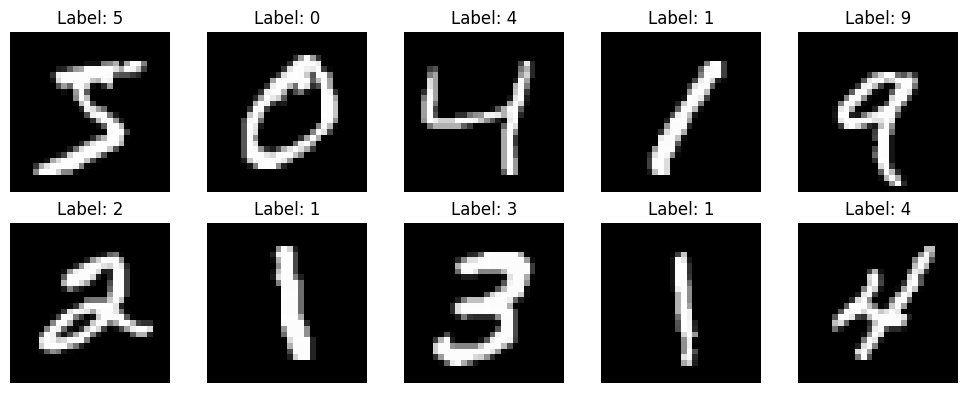

In [4]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Image preprocessing

In [5]:
# Normalize pixel values from 0-255 to 0-1.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# CNN expects: (samples, height, width, channels)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print('Preprocessed training shape:', x_train.shape)
print('Pixel range:', x_train.min(), 'to', x_train.max())

Preprocessed training shape: (60000, 28, 28, 1)
Pixel range: 0.0 to 1.0


## 5. Build the CNN model

In [6]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the CNN

In [7]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    validation_split=0.10,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 62s 143ms/step - accuracy: 0.9014 - loss: 0.3198 - val_accuracy: 0.9793 - val_loss: 0.0657
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 58s 138ms/step - accuracy: 0.9691 - loss: 0.1035 - val_accuracy: 0.9863 - val_loss: 0.0443
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 139ms/step - accuracy: 0.9759 - loss: 0.0783 - val_accuracy: 0.9897 - val_loss: 0.0354
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 136ms/step - accuracy: 0.9813 - loss: 0.0620 - val_accuracy: 0.9893 - val_loss: 0.0337
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 139ms/step - accuracy: 0.9828 - loss: 0.0543 - val_accuracy: 0.9932 - val_loss: 0.0286
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 60s 142ms/step - accuracy: 0.9850 - loss: 0.0488 - val_accuracy: 0.9908 - val_loss: 0.0324
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - accuracy: 0.9870 - loss: 0.0428 - val_accuracy: 0.9913 - val_loss: 0.0302


## 7. Plot training accuracy and loss

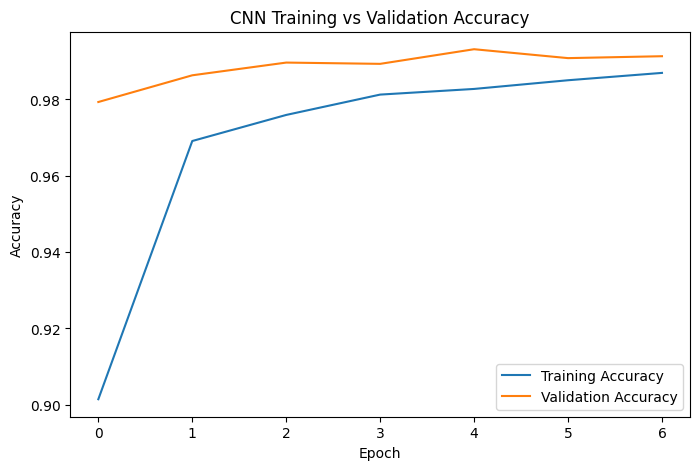

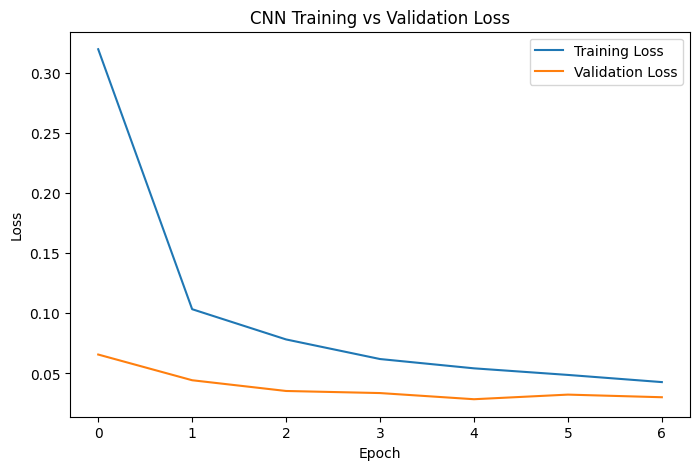

In [8]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.legend()
plt.show()

## 8. Evaluate the model on the test set

In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4%}')

Test Loss: 0.0283
Test Accuracy: 98.9800%


## 9. Predictions and classification metrics

In [10]:
probabilities = model.predict(x_test, verbose=0)
y_pred = np.argmax(probabilities, axis=1)

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9790    0.9980    0.9884       980
           1     0.9956    0.9991    0.9974      1135
           2     0.9913    0.9942    0.9927      1032
           3     0.9960    0.9891    0.9925      1010
           4     0.9939    0.9908    0.9924       982
           5     0.9811    0.9888    0.9849       892
           6     0.9968    0.9802    0.9884       958
           7     0.9864    0.9893    0.9879      1028
           8     0.9917    0.9825    0.9871       974
           9     0.9851    0.9841    0.9846      1009

    accuracy                         0.9898     10000
   macro avg     0.9897    0.9896    0.9896     10000
weighted avg     0.9898    0.9898    0.9898     10000



## 10. Confusion matrix

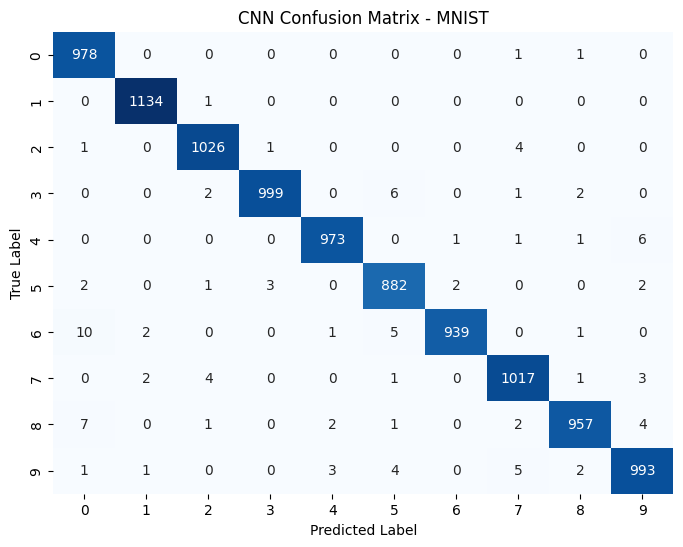

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix - MNIST')
plt.show()

## 11. Show correctly/incorrectly classified examples

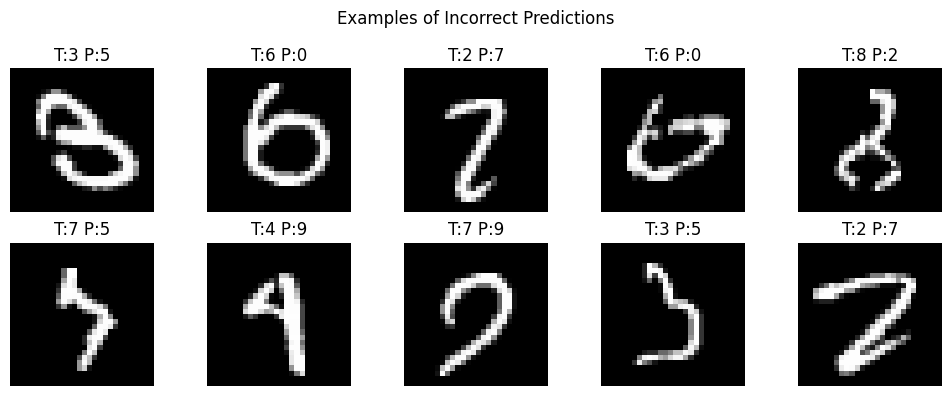

In [12]:
incorrect = np.where(y_pred != y_test)[0]
correct = np.where(y_pred == y_test)[0]

plt.figure(figsize=(10,4))
for j, idx in enumerate(incorrect[:10]):
    plt.subplot(2,5,j+1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f'T:{y_test[idx]} P:{y_pred[idx]}')
    plt.axis('off')
plt.suptitle('Examples of Incorrect Predictions')
plt.tight_layout()
plt.show()

## 12. Save/export the trained CNN model

In [13]:
os.makedirs('exports', exist_ok=True)
model_path = 'exports/handwritten_digit_cnn.keras'
model.save(model_path)

# Save class labels for future inference.
joblib.dump(list(range(10)), 'exports/class_labels.joblib')

print('CNN model saved to:', model_path)
print('Class labels saved to: exports/class_labels.joblib')

CNN model saved to: exports/handwritten_digit_cnn.keras
Class labels saved to: exports/class_labels.joblib


## 13. Test one handwritten image

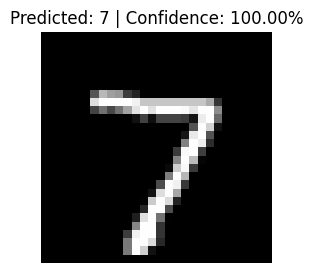

Actual digit   : 7
Predicted digit: 7
Confidence     : 100.00%


In [14]:
index = 0
sample = x_test[index:index+1]
probs = model.predict(sample, verbose=0)[0]
predicted_digit = int(np.argmax(probs))
confidence = float(np.max(probs))

plt.figure(figsize=(3,3))
plt.imshow(sample[0].squeeze(), cmap='gray')
plt.title(f'Predicted: {predicted_digit} | Confidence: {confidence:.2%}')
plt.axis('off')
plt.show()

print('Actual digit   :', int(y_test[index]))
print('Predicted digit:', predicted_digit)
print(f'Confidence     : {confidence:.2%}')

## 14. Download the trained model in Google Colab

In [15]:
from google.colab import files
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Extension to handwritten alphabets with EMNIST

The task also mentions EMNIST. EMNIST provides several splits, including **EMNIST Letters (26 classes)** and **EMNIST Balanced (47 classes)**, in 28×28 image format. citeturn0search0

To extend this project from digits to characters, replace the MNIST data-loading section with an EMNIST loader and change the final CNN Dense layer from `Dense(10, activation='softmax')` to the number of classes in the selected EMNIST split. For full words/sentences, a sequence model such as CRNN can be added after character segmentation.

## Final project workflow

Image Dataset → Preprocessing → CNN → Training → Validation → Test Evaluation → Confusion Matrix → Classification Report → Prediction → Export `.keras` Model.

**Note:** This notebook recognizes isolated handwritten digits. It does not automatically recognize arbitrary words or sentences; that requires segmentation plus a sequence-recognition pipeline.